Task 2:
This task is aiming to provide a binary classification of the column “Type”. 
The dataset is provided in two different tables ("table_1.csv" and "table_2.csv") 
with unique identifier of column “ID”. Tip: This column (ID) can be used to match the 
two tables.

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, balanced_accuracy_score, matthews_corrcoef,
                             confusion_matrix, classification_report, roc_curve, precision_recall_curve)

import warnings

warnings.filterwarnings("ignore")

In [43]:
df1 = pd.read_csv(r"C:\Users\ranga\OneDrive\Desktop\BMW-Tech-Works\Task 2\Dataset\table_1.csv", delimiter=';')
df2 = pd.read_csv(r"C:\Users\ranga\OneDrive\Desktop\BMW-Tech-Works\Task 2\Dataset\table_2.csv", delimiter=';')

In [44]:
data = pd.merge(df1, df2, on="ID", how="inner")
data.head()

,ID,UKL,GJAH,ZIK,HUI,ERZ,CDx,BJZHD,NKJUD,LPI,BJKG,POUG,TRE,ZUB,VOL,UIO,VBNM,Type,OIN
0,0,160,oooo,x,oooo,www,5.0,vvvv,80.0,800000.0,qqqq,1,1.750,t,f,uuuu,t,n,17.92
1,1,153,rrr,NaN,uuu,pppp,0.0,mmm,200.0,2000000.0,qqqq,0,0.290,f,f,wwww,f,n,16.92
2,1,153,rrr,NaN,uuu,pppp,0.0,mmm,200.0,2000000.0,qqqq,0,0.290,f,f,wwww,f,n,16.92
3,2,5,oooo,x,oooo,www,19.0,hh,96.0,960000.0,hh,1,0.000,f,f,wwww,t,n,31.25
4,3,9,oooo,NaN,oooo,www,120.0,kkk,0.0,0.0,qqq,0,0.335,f,f,uuuu,f,n,48.17


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      4475 non-null   int64  
 1   UKL     4475 non-null   int64  
 2   GJAH    4401 non-null   object 
 3   ZIK     1867 non-null   object 
 4   HUI     4475 non-null   object 
 5   ERZ     4401 non-null   object 
 6   CDx     4475 non-null   float64
 7   BJZHD   4398 non-null   object 
 8   NKJUD   4361 non-null   float64
 9   LPI     4361 non-null   float64
 10  BJKG    4398 non-null   object 
 11  POUG    4475 non-null   int64  
 12  TRE     4475 non-null   float64
 13  ZUB     4475 non-null   object 
 14  VOL     4475 non-null   object 
 15  UIO     4430 non-null   object 
 16  VBNM    4475 non-null   object 
 17  Type    4475 non-null   object 
 18  OIN     4429 non-null   float64
dtypes: float64(5), int64(3), object(11)
memory usage: 664.4+ KB


In [46]:
data.isna().sum()

ID          0
UKL         0
GJAH       74
ZIK      2608
HUI         0
ERZ        74
CDx         0
BJZHD      77
NKJUD     114
LPI       114
BJKG       77
POUG        0
TRE         0
ZUB         0
VOL         0
UIO        45
VBNM        0
Type        0
OIN        46
dtype: int64

In [47]:
data.describe()

,ID,UKL,CDx,NKJUD,LPI,POUG,TRE,OIN
count,4475.000000,4475.000000,4475.000000,4361.000000,4.361000e+03,4475.00000,4475.000000,4429.000000
mean,1838.977430,96.316872,2286.035531,163.132538,1.631325e+06,4.13743,3.392010,32.707180
std,1069.445348,56.013921,8938.486172,154.868928,1.548689e+06,6.73863,4.281415,12.602387
min,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000,13.750000
25%,898.500000,47.000000,0.000000,0.000000,0.000000e+00,0.00000,0.500000,22.920000
50%,1838.000000,101.000000,113.000000,120.000000,1.200000e+06,2.00000,1.750000,28.670000
75%,2766.500000,152.000000,1000.000000,280.000000,2.800000e+06,6.00000,5.000000,40.000000
max,3699.000000,179.000000,100000.000000,1160.000000,1.160000e+07,67.00000,28.500000,80.250000


In [48]:
# checking balance of output varaible
print(data["Type"].value_counts())
print(data['Type'].value_counts(normalize=True))

Type
y    4135
n     340
Name: count, dtype: int64
Type
y    0.924022
n    0.075978
Name: proportion, dtype: float64


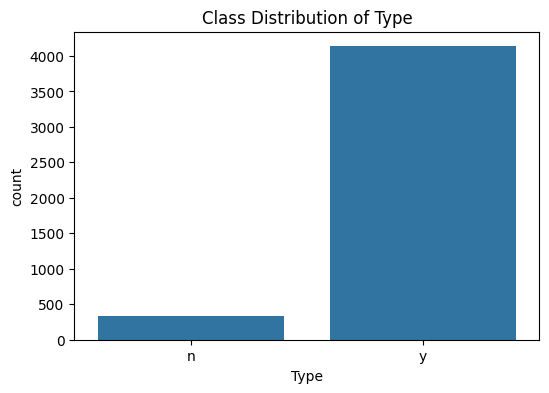

In [49]:
# class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Type', data=data)
plt.title('Class Distribution of Type')
plt.show()

- dataset imbalance is noticed, hence using RF classifier which has inbuilt class imbalance statergy

In [50]:
X = data.drop(['Type', 'ID'], axis=1)
y = data['Type']


categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
numerical_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]


# Preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [51]:
# Random Forest model with balanced class weights

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])


# test train Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


#  cross-validation
param_grid = {
    'classifier__n_estimators': [100,150, 200],
    'classifier__max_depth': [5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring=scoring, 
                           refit='roc_auc', n_jobs=-1, verbose=1)


grid_search.fit(X_train, y_train)

# Evaluating chosen model on the test set 
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, pos_label=best_model.classes_[1])
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test ROC AUC: {test_roc_auc:.4f}")

# final chosen model training
final_model = best_model.fit(X, y)
print("Final model trained on the full dataset with parameters:", grid_search.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Test Accuracy: 0.9911
Test F1 Score: 0.9952
Test ROC AUC: 1.0000
Final model trained on the full dataset with parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 150}


Evaluation Metrics for the Best Model:
Test Accuracy: 1.0000
Test Precision: 1.0000
Test Recall: 1.0000
Test F1 Score: 1.0000
Test ROC AUC: 1.0000
Test Log Loss: 0.0049
Balanced Accuracy: 1.0000
Matthews Correlation Coefficient: 1.0000



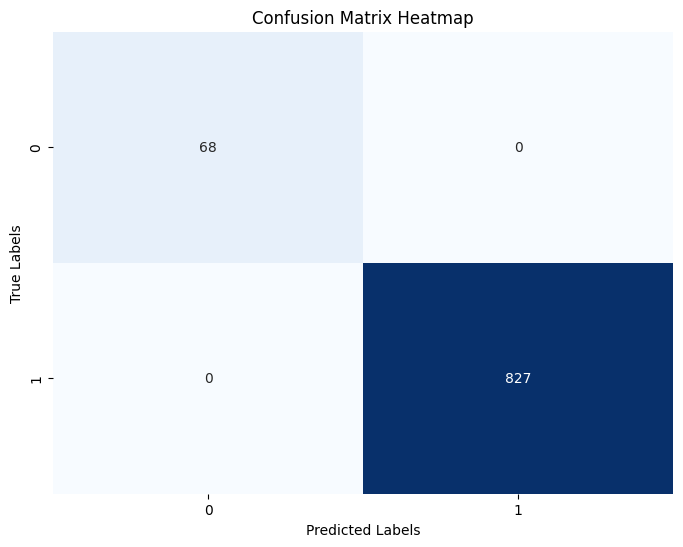


Classification Report:
              precision    recall  f1-score   support

           n       1.00      1.00      1.00        68
           y       1.00      1.00      1.00       827

    accuracy                           1.00       895
   macro avg       1.00      1.00      1.00       895
weighted avg       1.00      1.00      1.00       895



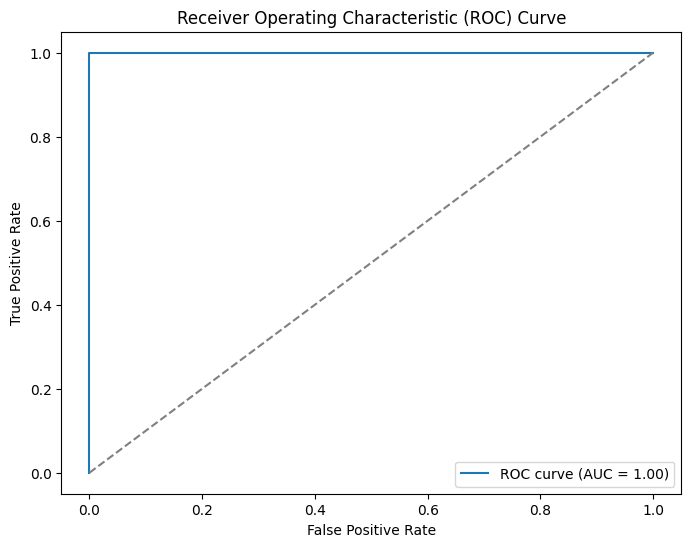

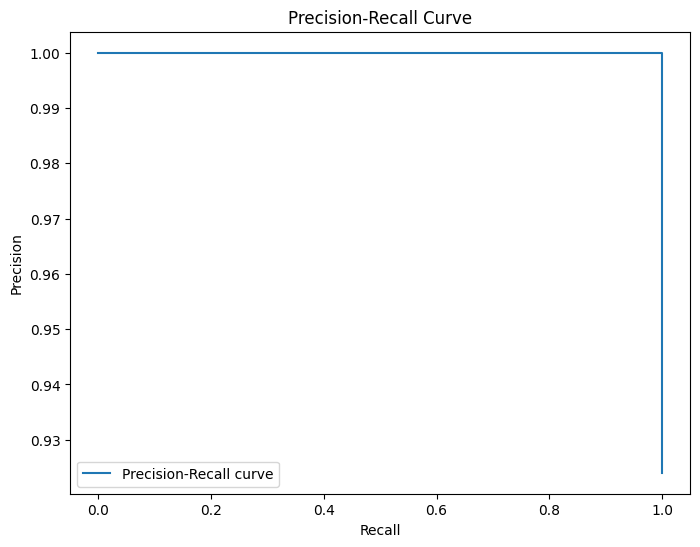

In [52]:
# Predictions and predicted probabilities 
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=best_model.classes_[1])
recall = recall_score(y_test, y_pred, pos_label=best_model.classes_[1])
f1 = f1_score(y_test, y_pred, pos_label=best_model.classes_[1])
roc_auc = roc_auc_score(y_test, y_pred_proba)
logloss = log_loss(y_test, y_pred_proba)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
matthews = matthews_corrcoef(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


print("Evaluation Metrics for the Best Model:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")
print(f"Test Log Loss: {logloss:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Matthews Correlation Coefficient: {matthews:.4f}\n")

# Confusion matrix and classification report
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()
print("\nClassification Report:")
print(class_report)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=best_model.classes_[1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_pred_proba, pos_label=best_model.classes_[1])
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label="Precision-Recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

